In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tensorflow

In [3]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential


In [4]:
df = pd.read_csv("/content/drive/MyDrive/skripsi/mental_health.csv")  # ubah path sesuai lokasi dataset kamu
df.head()


,text,label
0,dear american teens question dutch person hear...,0
1,nothing look forward lifei dont many reasons k...,1
2,music recommendations im looking expand playli...,0
3,im done trying feel betterthe reason im still ...,1
4,worried year old girl subject domestic physic...,1


In [5]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27977 entries, 0 to 27976
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    27977 non-null  object
 1   label   27977 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 437.3+ KB


,label
count,27977.000000
mean,0.494621
std,0.499980
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


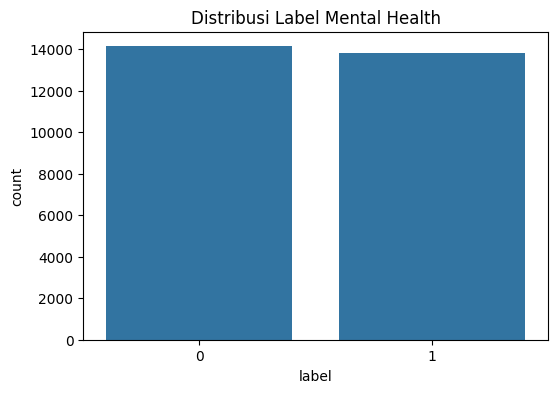

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')
plt.title("Distribusi Label Mental Health")
plt.show()


In [7]:
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
df['text_len'].describe()

,text_len
count,27977.000000
mean,71.759410
std,103.802417
min,0.000000
25%,16.000000
50%,38.000000
75%,87.000000
max,2676.000000


In [8]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+"," ", text)              # hapus URL
    text = re.sub(r"[^a-zA-Z']"," ", text)           # hanya alfabet
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words] # hapus stopwords
    return " ".join(words)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [9]:
df['clean_text'] = df['text'].apply(clean_text)
df.head()

,text,label,text_len,clean_text
0,dear american teens question dutch person hear...,0,23,dear american teens question dutch person hear...
1,nothing look forward lifei dont many reasons k...,1,20,nothing look forward lifei dont many reasons k...
2,music recommendations im looking expand playli...,0,64,music recommendations im looking expand playli...
3,im done trying feel betterthe reason im still ...,1,100,im done trying feel betterthe reason im still ...
4,worried year old girl subject domestic physic...,1,311,worried year old girl subject domestic physica...


In [10]:
MAX_WORDS = 20000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(X, maxlen=MAX_LEN)

y = df['label']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
EMBEDDING_DIM = 300
embedding_index = {}

glove_path = "/content/drive/MyDrive/dolma_300_2024_1.2M.100_combined.txt"

with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vectors = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vectors

print("Total words in GloVe:", len(embedding_index))


Total words in GloVe: 1200001


In [13]:
word_index = tokenizer.word_index
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < MAX_WORDS:
        vect = embedding_index.get(word)
        if vect is not None:
            embedding_matrix[i] = vect


In [14]:
model = Sequential([
    Embedding(MAX_WORDS, EMBEDDING_DIM, weights=[embedding_matrix],
              input_length=MAX_LEN, trainable=False),

    LSTM(128, return_sequences=False),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.4),

    Dense(1, activation='sigmoid')  # untuk binary classification
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

In [15]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 274ms/step - accuracy: 0.7863 - loss: 0.4381 - val_accuracy: 0.8805 - val_loss: 0.2854
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 76s 272ms/step - accuracy: 0.8963 - loss: 0.2619 - val_accuracy: 0.9080 - val_loss: 0.2290
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 77s 274ms/step - accuracy: 0.9135 - loss: 0.2205 - val_accuracy: 0.9169 - val_loss: 0.2095
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 77s 276ms/step - accuracy: 0.9180 - loss: 0.2076 - val_accuracy: 0.9276 - val_loss: 0.1885
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 75s 269ms/step - accuracy: 0.9291 - loss: 0.1815 - val_accuracy: 0.9305 - val_loss: 0.1816
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 78s 280ms/step - accuracy: 0.9354 - loss: 0.1667 - val_accuracy: 0.9301 - val_loss: 0.1805
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 285ms/step - accuracy: 0.9403 - loss: 0.1519 - val_accuracy: 0.9312 - val_loss: 0.1870
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 78s 279ms/step - accuracy: 0.9494 - loss: 0

175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step
Accuracy: 0.9354896354538956
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      2802
           1       0.92      0.95      0.94      2794

    accuracy                           0.94      5596
   macro avg       0.94      0.94      0.94      5596
weighted avg       0.94      0.94      0.94      5596



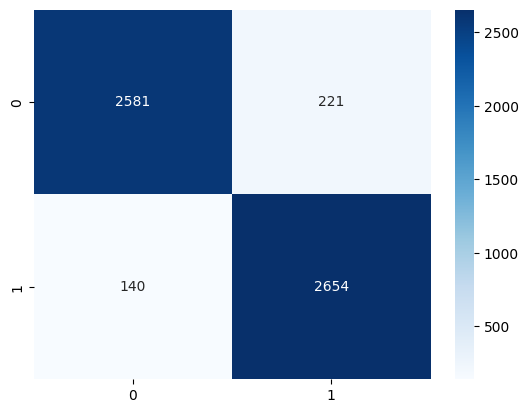

In [16]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()


In [17]:
def predict_text(sentence):
    clean = clean_text(sentence)
    seq = tokenizer.texts_to_sequences([clean])
    pad = pad_sequences(seq, maxlen=MAX_LEN)
    prob = model.predict(pad)[0][0]

    if prob > 0.5:
        print("🟣 Kondisi mental: BERMASALAH (1)")
    else:
        print("🟢 Kondisi mental: NORMAL (0)")

    print("Probability:", prob)


In [18]:
#cek fungsi cleaning teks
print("=== TEST CLEAN TEXT ===")
test_sentence = "Hello!!! I'm feeling very sad today... :("
print("Before :", test_sentence)
print("After  :", clean_text(test_sentence))


=== TEST CLEAN TEXT ===
Before : Hello!!! I'm feeling very sad today... :(
After  : hello im feeling sad today


In [19]:
#cek tokenizer bekerja
print("\n=== TEST TOKENIZER ===")
seq = tokenizer.texts_to_sequences([clean_text(test_sentence)])
print("Tokenized:", seq)

pad = pad_sequences(seq, maxlen=MAX_LEN)
print("Padded:", pad)
print("Shape padded:", pad.shape)



=== TEST TOKENIZER ===
Tokenized: [[1196, 2, 96, 178, 148]]
Padded: [[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0 1196    2   96
   178  148]]
Shape padded: (1, 100)


In [20]:
#cek apakah kata ada di embedding dlove
print("\n=== TEST GLOVE WORD VECTOR ===")
sample_word = "mad"
if sample_word in embedding_index:
    print(f"'{sample_word}' found in GloVe, vector length:", len(embedding_index[sample_word]))
else:
    print(f"'{sample_word}' NOT found in GloVe")



=== TEST GLOVE WORD VECTOR ===
'mad' found in GloVe, vector length: 300


In [21]:
#cek embedding matrix ukuran benar

In [22]:
print("\n=== TEST EMBEDDING MATRIX ===")
print("Embedding matrix shape:", embedding_matrix.shape)

# coba lihat 1 baris embedding pertama
print("First row example:", embedding_matrix[1][:10])



=== TEST EMBEDDING MATRIX ===
Embedding matrix shape: (20000, 300)
First row example: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [23]:
#cek apakah model bisa forward pass
print("\n=== TEST MODEL FORWARD PASS ===")
try:
    out = model.predict(pad)
    print("Model output:", out)
    print("Forward pass OK!")
except Exception as e:
    print("Error during forward pass:", e)



=== TEST MODEL FORWARD PASS ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Model output: [[0.0093098]]
Forward pass OK!


In [24]:
#cek fungsi prediksi custom
print("\n=== TEST CUSTOM PREDICT FUNCTION ===")
try:
    predict_text("I’m not in any kind of trouble, but somehow I feel tired. It feels like I want to disappear from this world. I’m not even having financial problems or any physical illness. I’m just really exhausted")
    print("predict_text() works fine!")
except Exception as e:
    print("Error in predict_text():", e)



=== TEST CUSTOM PREDICT FUNCTION ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
🟣 Kondisi mental: BERMASALAH (1)
Probability: 0.7948533
predict_text() works fine!


In [25]:
#cek 5 sempel data apakah dapat di proses
print("\n=== TEST MULTIPLE SAMPLES FROM DATASET ===")

try:
    samples = df['text'].iloc[:5].tolist()
    for i, text in enumerate(samples):
        print("\nSample", i+1)
        predict_text(text)
    print("\nMultiple sample prediction OK!")
except Exception as e:
    print("Error on dataset sample prediction:", e)



=== TEST MULTIPLE SAMPLES FROM DATASET ===

Sample 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
🟢 Kondisi mental: NORMAL (0)
Probability: 1.2602237e-06

Sample 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
🟣 Kondisi mental: BERMASALAH (1)
Probability: 0.99900883

Sample 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
🟢 Kondisi mental: NORMAL (0)
Probability: 3.388552e-07

Sample 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
🟣 Kondisi mental: BERMASALAH (1)
Probability: 0.9961277

Sample 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
🟣 Kondisi mental: BERMASALAH (1)
Probability: 0.98285747

Multiple sample prediction OK!
